# Within-Protein Normalized Autocorrelation Features

The disagreement analysis showed that **per-residue autocorrelation** is consistently higher
in multi-state replicates compared to single-state replicates of the same protein.

Strategy:
1. Compute per-residue dynamics features from early trajectory segments
2. Z-score normalize within each receptor (removes cross-protein baseline)
3. Pool all normalized trajectories
4. Train classifiers on normalized features

This tests: **after removing protein identity, can within-protein variation predict multistate behavior?**

In [4]:
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.spatial.distance import pdist, squareform
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    balanced_accuracy_score, confusion_matrix, classification_report
)
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

METADATA_CSV = "../data/metadata/metadata.csv"
CA_COORD_DIR = Path("../../gcs_mount/data/ca_coords")
RESULTS_DIR = Path("../results/autocorrelation_experiment")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

SKIP_EQ = 100
EARLY_FRAC = 0.5
N_BINS = 20  # bin residues into fixed-size regions

## Step 1: Compute Per-Residue Dynamics Features

In [5]:
def kabsch_align(mobile, reference):
    mobile_c = mobile - mobile.mean(axis=0)
    ref_c = reference - reference.mean(axis=0)
    H = mobile_c.T @ ref_c
    V, _, Wt = np.linalg.svd(H)
    if np.linalg.det(V @ Wt) < 0:
        V[:, -1] *= -1
    return mobile_c @ (V @ Wt)


def find_npy(receptor, rep, simID, npy_dir):
    npy_dir = Path(npy_dir)
    receptor_clean = str(receptor).replace('~', '_')
    rep = int(float(rep))
    simID = int(float(simID))
    for name in [
        f"{receptor_clean}_rep{rep}_{simID}.npy",
        f"{receptor_clean}_sim{simID}_rep{rep}.npy",
    ]:
        p = npy_dir / name
        if p.exists():
            return p
    return None


def compute_residue_features(ca_coords, skip_eq=100, frac=0.5, n_bins=20):
    """
    Compute per-residue dynamics features from early trajectory, then bin
    into fixed-size regions for cross-protein comparability.
    
    Returns: feature vector of fixed size (n_bins * n_feature_types)
    """
    n_frames = ca_coords.shape[0]
    start = min(skip_eq, n_frames - 1)
    n_use = max(1, int((n_frames - start) * frac))
    frames = ca_coords[start:start + n_use].astype(np.float64)
    
    # Align to first frame
    ref = frames[0].copy()
    aligned = np.zeros_like(frames)
    for i in range(len(frames)):
        aligned[i] = kabsch_align(frames[i], ref)
    
    n_fr, n_res, _ = aligned.shape
    
    # Per-residue features
    mean_pos = aligned.mean(axis=0)
    
    # 1. RMSF
    rmsf = np.sqrt(((aligned - mean_pos) ** 2).sum(axis=2).mean(axis=0))
    
    # 2. Displacement mean and std
    displacements = np.sqrt(((aligned[1:] - aligned[:-1]) ** 2).sum(axis=2))
    disp_mean = displacements.mean(axis=0)
    disp_std = displacements.std(axis=0)
    
    # 3. Autocorrelation (lag-1) of distance from mean position
    autocorr = np.zeros(n_res)
    for r in range(n_res):
        dist_from_mean = np.sqrt(((aligned[:, r, :] - mean_pos[r]) ** 2).sum(axis=1))
        if dist_from_mean.std() > 1e-10 and len(dist_from_mean) > 2:
            autocorr[r] = np.corrcoef(dist_from_mean[:-1], dist_from_mean[1:])[0, 1]
    
    # 4. Multi-lag autocorrelation (lag-5, lag-10)
    autocorr_5 = np.zeros(n_res)
    autocorr_10 = np.zeros(n_res)
    for r in range(n_res):
        dist_from_mean = np.sqrt(((aligned[:, r, :] - mean_pos[r]) ** 2).sum(axis=1))
        if dist_from_mean.std() > 1e-10:
            if len(dist_from_mean) > 6:
                autocorr_5[r] = np.corrcoef(dist_from_mean[:-5], dist_from_mean[5:])[0, 1]
            if len(dist_from_mean) > 11:
                autocorr_10[r] = np.corrcoef(dist_from_mean[:-10], dist_from_mean[10:])[0, 1]
    
    # 5. Pairwise distance variance (how much do contacts fluctuate?)
    # Sample every 10th frame for speed
    sample_idx = np.arange(0, len(aligned), max(1, len(aligned) // 50))
    dist_matrices = []
    for i in sample_idx:
        dist_matrices.append(squareform(pdist(aligned[i])))
    dist_stack = np.array(dist_matrices)
    contact_var = dist_stack.var(axis=0)  # (n_res, n_res)
    contact_var_per_res = contact_var.mean(axis=1)  # (n_res,)
    
    # Bin all per-residue features into fixed-size regions
    per_residue = {
        'rmsf': rmsf,
        'disp_mean': disp_mean,
        'disp_std': disp_std,
        'autocorr_1': autocorr,
        'autocorr_5': autocorr_5,
        'autocorr_10': autocorr_10,
        'contact_var': contact_var_per_res,
    }
    
    bin_edges = np.linspace(0, n_res, n_bins + 1).astype(int)
    
    feature_vec = []
    feature_names = []
    
    for feat_name, feat_vals in per_residue.items():
        for b in range(n_bins):
            bin_vals = feat_vals[bin_edges[b]:bin_edges[b+1]]
            if len(bin_vals) > 0:
                feature_vec.append(np.nanmean(bin_vals))
                feature_names.append(f"{feat_name}_bin{b}")
            else:
                feature_vec.append(0.0)
                feature_names.append(f"{feat_name}_bin{b}")
    
    # Also add global summary stats
    for feat_name, feat_vals in per_residue.items():
        for agg_name, agg_fn in [('mean', np.nanmean), ('std', np.nanstd),
                                   ('max', np.nanmax), ('median', np.nanmedian)]:
            feature_vec.append(float(agg_fn(feat_vals)))
            feature_names.append(f"{feat_name}_{agg_name}")
    
    return np.array(feature_vec, dtype=np.float32), feature_names

In [6]:
# Compute features for all trajectories
df = pd.read_csv(METADATA_CSV)

all_features = []
all_labels = []
all_receptors = []
all_families = []
feature_names = None

for idx, row in df.iterrows():
    path = find_npy(row['receptor'], row['rep'], row['simID'], CA_COORD_DIR)
    if path is None:
        continue
    
    try:
        ca_coords = np.load(path)
        feat_vec, names = compute_residue_features(ca_coords, SKIP_EQ, EARLY_FRAC, N_BINS)
        all_features.append(feat_vec)
        all_labels.append(int(row['y']))
        all_receptors.append(row['receptor'])
        all_families.append(row.get('family', 'Unknown'))
        if feature_names is None:
            feature_names = names
    except Exception as e:
        print(f"  Error {row['receptor']}: {e}")
    
    if (idx + 1) % 50 == 0:
        print(f"  Processed {idx + 1}/{len(df)}")

X_raw = np.array(all_features)
y = np.array(all_labels)
receptors = np.array(all_receptors)
families = np.array(all_families)

print(f"\nComputed features for {len(X_raw)} trajectories")
print(f"Feature dimension: {X_raw.shape[1]}")
print(f"Multi: {y.sum()}, Single: {(y==0).sum()}")
print(f"Feature types: {len(set(n.rsplit('_', 1)[0] for n in feature_names))} "
      f"({N_BINS} bins + 4 summary stats each)")

  Processed 50/247
  Processed 100/247
  Processed 150/247
  Processed 200/247

Computed features for 246 trajectories
Feature dimension: 168
Multi: 71, Single: 175
Feature types: 7 (20 bins + 4 summary stats each)


## Step 2: Within-Receptor Z-Score Normalization

For each receptor with multiple trajectories, compute the mean and std
of each feature across its replicates, then z-score normalize.
This removes the protein-specific baseline, leaving only within-protein variation.

Receptors with only one trajectory are excluded (can't normalize).

In [7]:
# Z-score normalize within each receptor
receptor_groups = pd.DataFrame({
    'receptor': receptors,
    'y': y,
    'family': families,
    'idx': range(len(y)),
})

# Only keep receptors with 2+ trajectories
receptor_counts = receptor_groups['receptor'].value_counts()
multi_traj_receptors = receptor_counts[receptor_counts >= 2].index

X_norm_list = []
y_norm_list = []
receptor_norm_list = []
family_norm_list = []

for rec in multi_traj_receptors:
    mask = receptors == rec
    X_rec = X_raw[mask]
    y_rec = y[mask]
    fam_rec = families[mask]
    
    # Z-score within this receptor
    rec_mean = X_rec.mean(axis=0)
    rec_std = X_rec.std(axis=0)
    rec_std[rec_std < 1e-10] = 1.0  # avoid division by zero for constant features
    
    X_z = (X_rec - rec_mean) / rec_std
    
    for i in range(len(X_z)):
        X_norm_list.append(X_z[i])
        y_norm_list.append(y_rec[i])
        receptor_norm_list.append(rec)
        family_norm_list.append(fam_rec[i])

X_norm = np.array(X_norm_list)
y_norm = np.array(y_norm_list)
receptors_norm = np.array(receptor_norm_list)
families_norm = np.array(family_norm_list)

# Handle NaN/inf from normalization
X_norm = np.nan_to_num(X_norm, nan=0.0, posinf=0.0, neginf=0.0)

print(f"After within-receptor normalization:")
print(f"  Trajectories: {len(X_norm)}")
print(f"  Receptors: {len(set(receptors_norm))}")
print(f"  Multi: {y_norm.sum()}, Single: {(y_norm==0).sum()}")

After within-receptor normalization:
  Trajectories: 172
  Receptors: 69
  Multi: 49, Single: 123


## Step 3: Evaluate with Leave-One-Receptor-Out Cross-Validation

To avoid data leakage, we hold out all trajectories of one receptor at a time.
This is the strictest evaluation: the model never sees any replicate of the test protein.

In [8]:
from sklearn.model_selection import GroupKFold

def evaluate_classifier(clf, X, y, groups, clf_name=""):
    """
    Leave-one-receptor-out cross-validation.
    """
    unique_groups = np.unique(groups)
    all_preds = np.zeros(len(y))
    all_true = y.copy()
    
    for group in unique_groups:
        test_mask = groups == group
        train_mask = ~test_mask
        
        X_train, X_test = X[train_mask], X[test_mask]
        y_train = y[train_mask]
        
        # Skip if train set has only one class
        if len(np.unique(y_train)) < 2:
            all_preds[test_mask] = 0.5
            continue
        
        scaler = StandardScaler()
        X_train_s = scaler.fit_transform(X_train)
        X_test_s = scaler.transform(X_test)
        
        clf_copy = clf.__class__(**clf.get_params())
        clf_copy.fit(X_train_s, y_train)
        
        if hasattr(clf_copy, 'predict_proba'):
            all_preds[test_mask] = clf_copy.predict_proba(X_test_s)[:, 1]
        else:
            all_preds[test_mask] = clf_copy.decision_function(X_test_s)
    
    # Metrics
    auroc = roc_auc_score(all_true, all_preds)
    ap = average_precision_score(all_true, all_preds)
    preds_binary = (all_preds > 0.5).astype(int)
    bal_acc = balanced_accuracy_score(all_true, preds_binary)
    cm = confusion_matrix(all_true, preds_binary)
    
    print(f"  {clf_name}:")
    print(f"    AUROC={auroc:.3f}, AP={ap:.3f}, Bal Acc={bal_acc:.3f}")
    print(f"    CM: TN={cm[0,0]}, FP={cm[0,1]}, FN={cm[1,0]}, TP={cm[1,1]}")
    
    return {
        'classifier': clf_name,
        'auroc': auroc,
        'ap': ap,
        'bal_acc': bal_acc,
        'preds': all_preds,
    }

In [9]:
# Run classifiers on NORMALIZED features (within-receptor z-scored)
print("="*60)
print("  NORMALIZED FEATURES (within-receptor z-score)")
print("="*60)

classifiers = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
    'GradientBoosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'MLP': MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42),
    'SVM_RBF': SVC(kernel='rbf', probability=True, random_state=42, class_weight='balanced'),
}

norm_results = []
for name, clf in classifiers.items():
    result = evaluate_classifier(clf, X_norm, y_norm, receptors_norm, name)
    norm_results.append(result)

  NORMALIZED FEATURES (within-receptor z-score)
  LogisticRegression:
    AUROC=0.391, AP=0.243, Bal Acc=0.407
    CM: TN=70, FP=53, FN=37, TP=12
  RandomForest:
    AUROC=0.425, AP=0.245, Bal Acc=0.488
    CM: TN=120, FP=3, FN=49, TP=0
  GradientBoosting:
    AUROC=0.412, AP=0.241, Bal Acc=0.455
    CM: TN=107, FP=16, FN=47, TP=2
  MLP:
    AUROC=0.435, AP=0.295, Bal Acc=0.466
    CM: TN=92, FP=31, FN=40, TP=9
  SVM_RBF:
    AUROC=0.546, AP=0.313, Bal Acc=0.500
    CM: TN=123, FP=0, FN=49, TP=0


In [10]:
# Compare: RAW features (no normalization) — same evaluation
# Use only trajectories from multi-replicate receptors for fair comparison
multi_mask = np.isin(receptors, list(multi_traj_receptors))
X_raw_multi = X_raw[multi_mask]
y_raw_multi = y[multi_mask]
receptors_raw_multi = receptors[multi_mask]

print("\n" + "="*60)
print("  RAW FEATURES (no normalization, same trajectories)")
print("="*60)

raw_results = []
for name, clf in classifiers.items():
    result = evaluate_classifier(clf, X_raw_multi, y_raw_multi, receptors_raw_multi, name)
    raw_results.append(result)


  RAW FEATURES (no normalization, same trajectories)
  LogisticRegression:
    AUROC=0.440, AP=0.272, Bal Acc=0.450
    CM: TN=68, FP=55, FN=32, TP=17
  RandomForest:
    AUROC=0.454, AP=0.259, Bal Acc=0.484
    CM: TN=119, FP=4, FN=49, TP=0
  GradientBoosting:
    AUROC=0.442, AP=0.243, Bal Acc=0.423
    CM: TN=84, FP=39, FN=41, TP=8
  MLP:
    AUROC=0.486, AP=0.271, Bal Acc=0.478
    CM: TN=90, FP=33, FN=38, TP=11
  SVM_RBF:
    AUROC=0.175, AP=0.181, Bal Acc=0.500
    CM: TN=123, FP=0, FN=49, TP=0


In [11]:
# Also try CROSS-PROTEIN evaluation on ALL trajectories with raw features
# (holdout families, same as main experiments)
HOLDOUT_FAMILIES = ["Peptide", "Adenosine", "Serotonin"]

print("\n" + "="*60)
print("  RAW FEATURES — CROSS-PROTEIN (holdout families)")
print("="*60)

test_mask_cp = np.isin(families, HOLDOUT_FAMILIES)
X_train_cp = X_raw[~test_mask_cp]
X_test_cp = X_raw[test_mask_cp]
y_train_cp = y[~test_mask_cp]
y_test_cp = y[test_mask_cp]

print(f"  Train: {len(X_train_cp)} (multi={y_train_cp.sum()})")
print(f"  Test: {len(X_test_cp)} (multi={y_test_cp.sum()})")

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train_cp)
X_test_s = scaler.transform(X_test_cp)

cp_results = []
for name, clf in classifiers.items():
    clf.fit(X_train_s, y_train_cp)
    if hasattr(clf, 'predict_proba'):
        y_prob = clf.predict_proba(X_test_s)[:, 1]
    else:
        y_prob = clf.decision_function(X_test_s)
    y_pred = (y_prob > 0.5).astype(int)
    
    auroc = roc_auc_score(y_test_cp, y_prob)
    ap = average_precision_score(y_test_cp, y_prob)
    bal_acc = balanced_accuracy_score(y_test_cp, y_pred)
    cm = confusion_matrix(y_test_cp, y_pred)
    
    print(f"  {name}: AUROC={auroc:.3f}, AP={ap:.3f}, Bal Acc={bal_acc:.3f}")
    print(f"    CM: TN={cm[0,0]}, FP={cm[0,1]}, FN={cm[1,0]}, TP={cm[1,1]}")
    cp_results.append({'classifier': name, 'auroc': auroc, 'ap': ap, 'bal_acc': bal_acc})


  RAW FEATURES — CROSS-PROTEIN (holdout families)
  Train: 189 (multi=49)
  Test: 57 (multi=22)
  LogisticRegression: AUROC=0.351, AP=0.326, Bal Acc=0.371
    CM: TN=18, FP=17, FN=17, TP=5
  RandomForest: AUROC=0.507, AP=0.384, Bal Acc=0.500
    CM: TN=35, FP=0, FN=22, TP=0
  GradientBoosting: AUROC=0.514, AP=0.462, Bal Acc=0.519
    CM: TN=30, FP=5, FN=18, TP=4
  MLP: AUROC=0.456, AP=0.379, Bal Acc=0.525
    CM: TN=24, FP=11, FN=14, TP=8
  SVM_RBF: AUROC=0.362, AP=0.312, Bal Acc=0.500
    CM: TN=35, FP=0, FN=22, TP=0


In [12]:
# Summary comparison
print("\n" + "="*60)
print("  SUMMARY COMPARISON")
print("="*60)
print(f"\n{'Classifier':<25s} {'Norm AUROC':>10s} {'Raw AUROC':>10s} {'CrossProt':>10s}")
print(f"{'-'*25} {'-'*10} {'-'*10} {'-'*10}")
for nr, rr, cr in zip(norm_results, raw_results, cp_results):
    print(f"{nr['classifier']:<25s} {nr['auroc']:>10.3f} {rr['auroc']:>10.3f} {cr['auroc']:>10.3f}")

print(f"\nIf Norm >> Raw: within-protein normalization unlocks hidden signal.")
print(f"If Norm ≈ Raw ≈ 0.5: the autocorrelation signal is too weak even within-protein.")
print(f"If Norm > 0.5 but CrossProt ≈ 0.5: signal exists but doesn't transfer across proteins.")


  SUMMARY COMPARISON

Classifier                Norm AUROC  Raw AUROC  CrossProt
------------------------- ---------- ---------- ----------
LogisticRegression             0.391      0.440      0.351
RandomForest                   0.425      0.454      0.507
GradientBoosting               0.412      0.442      0.514
MLP                            0.435      0.486      0.456
SVM_RBF                        0.546      0.175      0.362

If Norm >> Raw: within-protein normalization unlocks hidden signal.
If Norm ≈ Raw ≈ 0.5: the autocorrelation signal is too weak even within-protein.
If Norm > 0.5 but CrossProt ≈ 0.5: signal exists but doesn't transfer across proteins.



Best normalized model: SVM_RBF (AUROC=0.546)


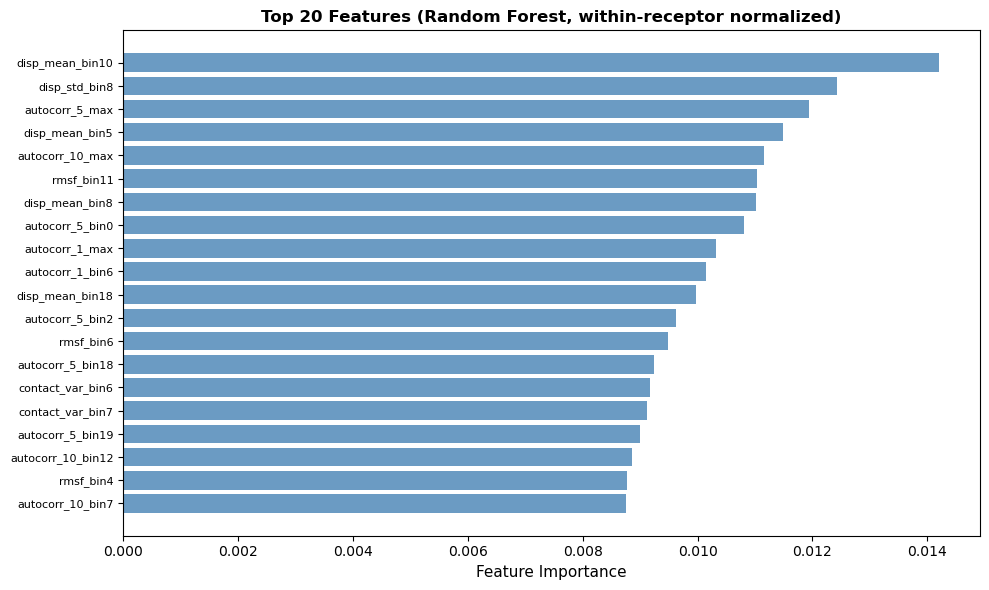


Autocorrelation features in top 20: 10/20


In [13]:
# Feature importance from best model
best_norm = max(norm_results, key=lambda r: r['auroc'])
print(f"\nBest normalized model: {best_norm['classifier']} (AUROC={best_norm['auroc']:.3f})")

# Retrain RF on all normalized data for feature importance
rf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
scaler_fi = StandardScaler()
X_fi = scaler_fi.fit_transform(X_norm)
rf.fit(X_fi, y_norm)

importances = rf.feature_importances_
top_idx = np.argsort(importances)[-20:][::-1]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(20), importances[top_idx][::-1], color='steelblue', alpha=0.8)
ax.set_yticks(range(20))
ax.set_yticklabels([feature_names[i] for i in top_idx][::-1], fontsize=8)
ax.set_xlabel('Feature Importance', fontsize=11)
ax.set_title('Top 20 Features (Random Forest, within-receptor normalized)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Count how many top features are autocorrelation-related
top_names = [feature_names[i] for i in top_idx]
n_autocorr = sum(1 for n in top_names if 'autocorr' in n)
print(f"\nAutocorrelation features in top 20: {n_autocorr}/20")

In [14]:
# Save all results
results_summary = pd.DataFrame([
    {**r, 'evaluation': 'normalized_LORO'} for r in norm_results
] + [
    {**r, 'evaluation': 'raw_LORO'} for r in raw_results
] + [
    {**r, 'evaluation': 'raw_cross_protein'} for r in cp_results
])
results_summary.to_csv(RESULTS_DIR / 'classifier_results.csv', index=False)
print(f"Saved: {RESULTS_DIR / 'classifier_results.csv'}")

Saved: ../results/autocorrelation_experiment/classifier_results.csv
